<a href="https://colab.research.google.com/github/sivasooryagiri/Learn-PyTorch-for-deep-learning-in-a-day--Notes/blob/main/03_Pytorch_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pytorch Computer Vision


In [ ]:
import torch
from torch import nn

# Vision

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Import Matplotlib
import matplotlib.pyplot as plt

# Check Virsion
print(torch.__version__)
print(torchvision.__version__)

2.8.0+cu126
0.23.0+cu126


# 1. Getting Data


In [ ]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True, # do we nee traing data?
    download=True,
    transform=ToTensor(), #How do we want to transform the data
    target_transform=None # how do we want to transform tatgets/labels
)

test_data= datasets.FashionMNIST(
    root="data",
    train=False, # do we nee traing data?
    download=True,
    transform=ToTensor(), #How do we want to transform the data
    target_transform=None # how do we want to transform tatgets/labels
)



In [ ]:
# indexing on first training data
image, label = train_data[3]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.1294, 0.3765, 0.6863, 0.6118, 0.2510, 0.0549, 0.2118, 0.5373,
           0.8000, 0.7608, 0.4000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2863, 0.7294,
           0.6941, 0.7176, 0.6863, 0.7373, 0.9098, 1.0000, 0.8745, 0.8588,
           0.7608, 0.7020, 0.7294, 0.8353, 0.5725, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1373, 0.6392, 0.5490,
           0.5882, 0.5961, 0.5882, 0.5725, 0.6863, 0.6863, 0.6784, 0.6706,
           0.6118, 0.5961, 0.5804, 0.5059, 0.6118, 0.5490, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.5882, 0.5569, 0.5490,
           0.5961, 0.6275, 0.6118, 0.5725, 0.5569, 0.4980, 0.5294, 0.5216,
           0.5490, 0.5490, 0.5373, 0.5216, 

In [ ]:
image.shape # [color_channel, height, width]

torch.Size([1, 28, 28])

In [ ]:
class_names = train_data.classes
class_names[2]


'Pullover'

###  Visualizing the Data

Text(0.5, 1.0, 'Ankle boot')

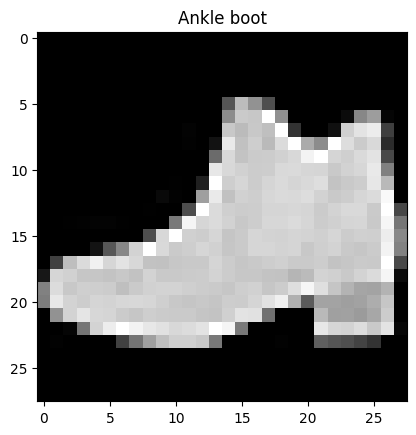

In [ ]:
import matplotlib.pyplot as plt
image, label = train_data[15]
plt.imshow(image.squeeze(),cmap="grey")
plt.title(class_names[label])

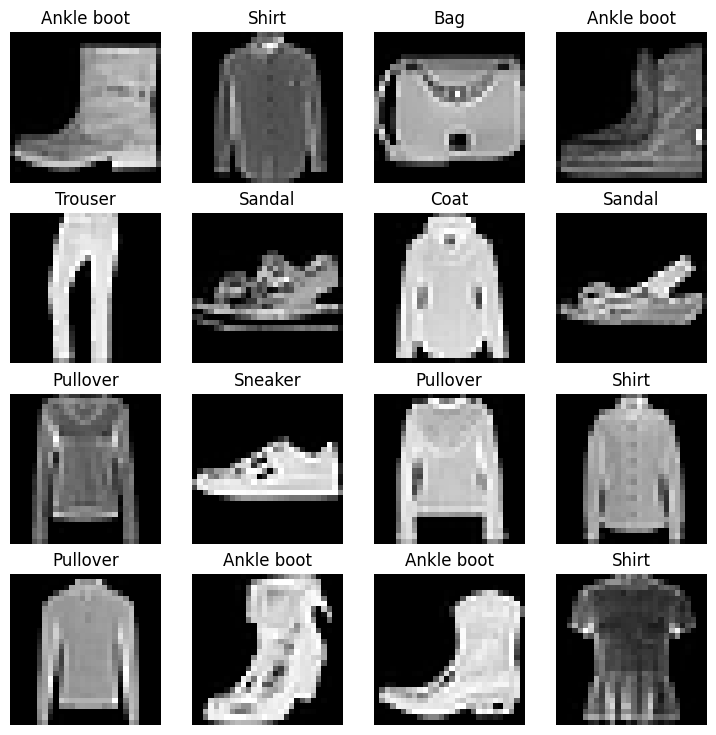

In [ ]:


torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 4,4

for i in range(1,rows*cols+1):
  random_idx = torch.randint(0,len(train_data),
  size=[1]).item()
  image, label = train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(image.squeeze(),cmap="grey",)
  plt.title(class_names[label])
  plt.axis(False)


# Creating mini Batches


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
# Turning Data into mini Batches
train_dataloader = DataLoader(dataset=train_data,
                               batch_size=BATCH_SIZE,
                               shuffle= True)

test_dataloader = DataLoader(dataset=test_data,
                               batch_size=BATCH_SIZE,
                               shuffle= True)
len(train_dataloader), len(test_dataloader)

(1875, 313)

In [ ]:
train_features_batch,train_lables_batch = next(iter(train_dataloader))
train_features_batch.shape,train_lables_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 8, label size: torch.Size([])


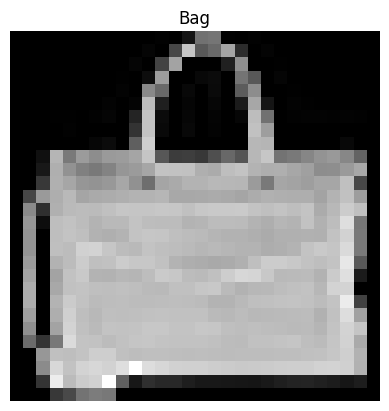

In [ ]:
# Show a Sample
# torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img,label = train_features_batch[random_idx], train_lables_batch[random_idx]

plt.imshow(img.squeeze(),cmap="grey")
plt.title(class_names[label])
plt.axis(False)
print(f'Image size: {img.shape}')
print(f'Label: {label}, label size: {label.shape}')

In [ ]:
# Starting to build a Model
flatern_model = nn.Flatten()

# Get a single sample
x = train_features_batch[0]

# Flatern the sample
output = flatern_model(x)

x.shape, output.shape

(torch.Size([1, 28, 28]), torch.Size([1, 784]))

In [ ]:
from torch import nn
class FashionMNISTModelV0 (nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )
  def forward(self,x):
    return self.layer_stack(x)

In [ ]:
torch.manual_seed(42)
model_0 = FashionMNISTModelV0(
    input_shape=784, # 28*28
    hidden_units=10,
    output_shape=len(class_names)
).to("cpu")
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
dummy_x = torch.rand([1,1,28,28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

## Set up Loss, Optimizer and evaluation metrics

In [ ]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper function alredy exists, skipping download....")
else:
  print("downloading...")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)
  print("downloaded")

helper function alredy exists, skipping download....


In [ ]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params = model_0.parameters(),
    lr = 0.1
)

### Finding how fanst model runs..
* Models performance and time matters,
and always carry a trade off between them


In [ ]:
from timeit import default_timer as timer
def print_train_time(
    start: float,
    end: float,
    device: torch.device = None):
  # Print diff bw start and end time
  total_time = end-start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time


## Creating training loop and training model on batches of data
1. Loop through epochs
2. Loop through trainig batchesn perform training steps, calculate the train loss per batch
3. Loop through testing data batches, perform testing steps, calculate testing loos
4. Print out whats happening.

In [ ]:
# imporing tqdm for Progress Bar
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epoch
epochs = 3

# Create training and test loop
for epoch in tqdm(range(epochs)):
  print(f"Epoch:{epoch}\n-----")
  ### Training
  train_loss = 0
  for batch, (X,y) in enumerate(train_dataloader):
    # training mode
    model_0.train()

    # Forward Pass
    y_pred = model_0(X)

    # Calculating the loss
    loss = loss_fn(y_pred,y)
    train_loss += loss

    # Optimizer zero grad
    optimizer.zero_grad()

    # Loss Backward
    loss.backward()

    # Optimizer Step
    optimizer.step()

    # Print what happening
    if batch % 400 == 0:
      print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples.")

  # Divide total train loss by length of train dataset
  train_loss /= len(train_dataloader)

  ## Testing mode
  test_loss, test_acc = 0,0
  with torch.inference_mode():
    for X_test, y_test in test_dataloader:
      # Forward Pass
      test_preds = model_0(X_test)

      # Calculate loss (accumulatively)
      test_loss += loss_fn(test_preds, y_test)

      # 3. Calculate Accuracy
      test_acc += accuracy_fn(y_true=y_test, y_pred=test_preds.argmax(dim=1))

    # Calculate avg test loss
    test_loss /= len(test_dataloader)

    # Calculate avg test acc
    test_acc /= len(test_dataloader)

  # Print out what's happening
  print(f"\nTrain loss: {train_loss:.4f} | Test loss: {test_loss:.4f}, Test_acc: {test_acc:.4f}")

# Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                            end=train_time_end_on_cpu,
                                            device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch:0
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.5904 | Test loss: 0.5102, Test_acc: 82.0387
Epoch:1
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.4743 | Test loss: 0.5268, Test_acc: 81.6793
Epoch:2
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.4537 | Test loss: 0.5126, Test_acc: 82.9972
Train time on cpu: 37.824 seconds


In [ ]:
str(next(model_0.parameters()).device)


'cpu'

# Make predictions and get Model 0 results

In [ ]:
device = "cpu"

In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn:0,
               device=device):
  """ Returns a dictionaty contining the results of  mode predicting on data_loader."""
  loss, acc = 0,0
  model.eval()
  with torch.inference_mode():
    for X,y in data_loader:
      X,y = X.to(device), y.to(device)
      # Make Predictions
      y_preds = model(X)

      # Accumulate the loss and acc values per batch
      loss += loss_fn(y_preds,y)
      acc += accuracy_fn(y,y_preds.argmax(dim=1))

      # Scale loss and acc to find the avg loss/acc per batch
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc}


# Calculate the loss
model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn = accuracy_fn,
                             device=device)
model_0_results


{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5119838714599609,
 'model_acc': 83.02715654952077}

# Setup device Agnostic code


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Model-1 Non Linear


In [ ]:
# Create a model with non-linear and linear layers
class FashionMNISTModelV1(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int) :
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape),
        nn.ReLU()
    )
  def forward(self,x: torch.Tensor):
    return self.layer_stack(x)



In [ ]:
torch.manual_seed(42)

model_1 = FashionMNISTModelV1(input_shape=784,
                              hidden_units=10,
                              output_shape=len(class_names)).to(device)

In [ ]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)


##Let's create test and train functions
* `train_step`= train
* `test_step`= test

In [ ]:
def train_step(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    accuracy_fn,
    device: torch.device = device):

  """ Perform training with model"""
  train_loss, train_acc = 0,0
  model.train()

  for batch, (X,y) in enumerate(data_loader):
    # training mode
    X,y = X.to(device),y.to(device)

    # Forward Pass
    y_pred = model(X)

    # Calculating the loss
    loss = loss_fn(y_pred,y)
    train_loss += loss
    train_acc += accuracy_fn(y, y_pred.argmax(dim=1))

    # Optimizer zero grad
    optimizer.zero_grad()

    # Loss Backward
    loss.backward()

    # Optimizer Step
    optimizer.step()

  # Divide total train loss and acc by length of train dataset
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)

  print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.5f}%")

In [ ]:
def test_step(model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy_fn,
    device: torch.device = device):
  """ Performs testing loop on model """
  test_loss, test_acc = 0,0
  model.eval()
  with torch.inference_mode():
    for X_test, y_test in data_loader:
      X_test,y_test = X_test.to(device), y_test.to(device)
      # Forward Pass
      test_preds = model(X_test)

      # Calculate loss (accumulatively)
      test_loss += loss_fn(test_preds, y_test)

      # 3. Calculate Accuracy
      test_acc += accuracy_fn(y_true=y_test, y_pred=test_preds.argmax(dim=1))

    # Calculate avg test loss
    test_loss /= len(data_loader)

    # Calculate avg test acc
    test_acc /= len(data_loader)

    # Print out what's happening
    print(f"\nTest loss: {test_loss:.4f}, Test_acc: {test_acc:.4f}% \n")


In [ ]:
torch.manual_seed(42)

# Measure Time
from timeit import default_timer as timer

train_time_start_on_gpu = timer()

epochs = 3

# Create a optimization and evaluation loop using train_step() and test_step()
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n----------")
  train_step(model=model_1,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)

  test_step(model=model_1,
             data_loader=test_dataloader,
             loss_fn=loss_fn,
             accuracy_fn=accuracy_fn,
             device=device)
  train_time_end_on_gpu = timer()
  total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                              end=train_time_end_on_gpu,
                                              device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
----------
Train loss: 1.09199 | Train acc: 61.34333%

Test loss: 0.9569, Test_acc: 64.9760% 

Train time on cuda: 12.172 seconds
Epoch: 1
----------
Train loss: 0.73779 | Train acc: 73.69333%

Test loss: 0.7239, Test_acc: 74.2113% 

Train time on cuda: 23.386 seconds
Epoch: 2
----------
Train loss: 0.66776 | Train acc: 76.07667%

Test loss: 0.6875, Test_acc: 75.6390% 

Train time on cuda: 34.224 seconds


In [ ]:
# Get model_1 results dictnory
model_1_results = eval_model(model=model_1,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6879839301109314,
 'model_acc': 75.62899361022365}

In [ ]:
# Get model_1 results dictnory
model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device='cpu')
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5119835138320923,
 'model_acc': 83.02715654952077}

# Model 2 Convelutional Neural Net



In [ ]:
class FashionMNISTModelV2(nn.Module):
  """Model achitecture that replicates TinyVGG"""
  def __init__(self, input_shape:int, hidden_units:int, output_shape:int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(start_dim=1),
        nn.Linear(in_features=hidden_units * 7 * 7, # work on this
                  out_features=output_shape)
    )

  def forward(self,x):
    x = self.conv_block_1(x)
    #print(x.shape)
    x = self.conv_block_2(x)
    #print(x.shape)
    x = self.classifier(x)
    #print(x.shape)
    return(x)



In [ ]:
len(class_names)

10

In [ ]:
model_2 = FashionMNISTModelV2(input_shape=1,
                              hidden_units=10,
                              output_shape=len(class_names)).to(device)

In [ ]:
# Setup loss/eval metrics/optimizer
from helper_functions import  accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)



# Training the model 2

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Train and test model

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-----------")
  train_step(model=model_2,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device
  )
  test_step(model=model_2,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)
  train_time_end_model_2 = timer()
  total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                              end=train_time_end_model_2,
                                              device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-----------
Train loss: 0.30465 | Train acc: 88.93333%

Test loss: 0.3049, Test_acc: 88.9776% 

Train time on cuda: 11.511 seconds
Epoch: 1
-----------
Train loss: 0.28873 | Train acc: 89.44167%

Test loss: 0.3429, Test_acc: 87.5300% 

Train time on cuda: 23.205 seconds
Epoch: 2
-----------
Train loss: 0.27895 | Train acc: 89.94833%

Test loss: 0.3038, Test_acc: 88.9677% 

Train time on cuda: 34.675 seconds


In [ ]:
# Model 2 results
model_2_results = eval_model(model=model_2,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3031848073005676,
 'model_acc': 88.9876198083067}

In [ ]:
import pandas
compare_results = pandas.DataFrame([model_0_results, model_1_results,model_2_results])

In [ ]:
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.511984,83.027157
1,FashionMNISTModelV1,0.687984,75.628994
2,FashionMNISTModelV2,0.303185,88.987620


In [ ]:
# Predicting with Model 2 and Test data
import random
model_2.eval()
with torch.inference_mode():
  for i in range(5):
    X,y = random.choice(test_data)
    pred = model_2(X.unsqueeze(0).to(device)).argmax()
    print(f"Test_y: {y} | Predicted_y: {pred}")
    if y!=pred:
      print("Model Failed here!!")

Test_y: 2 | Predicted_y: 2
Test_y: 2 | Predicted_y: 2
Test_y: 6 | Predicted_y: 2
Model Failed here!!
Test_y: 9 | Predicted_y: 7
Model Failed here!!
Test_y: 7 | Predicted_y: 7


tensor(8, device='cuda:0')